# RQ3 — What happens if you remove the most important player?

**Project:** Passing networks of the 2022 World Cup semi-finalists
**Course:** Analysis and Visualization of Complex Networks · Final project
**Reference lectures:** NS06 (centrality), NS07 (robustness), NS08 (null models)
**Reading:** Albert, Jeong & Barabási (2000), *Error and attack tolerance of complex networks*

---

## The question in brief

> *If we remove a team's most central player, how badly does its passing network break? And is that damage really worse than removing just any player?*

The question can be read two ways, and it is precisely the intersection of the two readings that makes it interesting. From the **network** point of view, it is a small-scale version of the targeted-attack experiment: remove a node and measure how much the structure suffers. Here, though, the networks are small (a few dozen nodes), weighted (the weight is the number of passes), directed and above all **very dense** — features that force us to choose robustness metrics different from those used in the original study by Albert, Jeong and Barabási. From the **football** point of view, we are asking how much the four 2022 semi-finalists depended on a single player to move the ball — a quantitative way of talking about something coaches understand perfectly well intuitively (the idea of a *midfield playmaker* or a *structural pivot*).

The notebook is divided into five parts, each building on the previous one:

| § | Section | What we do |
|---|---|---|
| 1 | **Starting point** | We load the four networks, report the basic statistics, and carry over the *top-1/top-2 betweenness ratio* seen in RQ1. |
| 2 | **How to measure damage** | The NS07 $S(q)$ does not work here, so we use two alternative metrics designed for dense networks. |
| 3 | **Removing one player** | Comparison between removing the pivot and removing a random player (n = 200), and a z-score for each team. |
| 4 | **Removing several players** | We remove the top-3 one after another, recomputing betweenness each time (the faithful version of Albert-Jeong-Barabási). |
| 5 | **Putting it all together** | Does RQ1's top-1/top-2 ratio actually predict which team is most fragile? A coherence check across the two experiments. |

Each section ends with a short recap (**What we learned**), so the thread is easy to reconstruct for the final report and so that anyone reading only the first and last line of each paragraph does not miss the key points.

A preliminary caveat: with only four teams, we are not doing statistics in the sense of drawing conclusions about a population. We are doing a *comparative case study* in which each team is described individually, and any correlation between dominance and fragility found in §5 should be read as an *internal consistency check* between two different experiments on the same data, not as a statistical finding with a p-value.


In [30]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc, FancyBboxPatch
from textwrap import fill
from scipy.stats import pearsonr, spearmanr

# same seed throughout the notebook.
RANDOM_SEED = 42
def set_seeds(seed=RANDOM_SEED):
    np.random.seed(seed)
    random.seed(seed)
set_seeds()

try:
    from IPython import get_ipython
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

plt.rcParams["figure.dpi"]     = 150
plt.rcParams["savefig.dpi"]    = 220
plt.rcParams["savefig.bbox"]   = "tight"
plt.rcParams["axes.grid"]      = False
plt.rcParams["font.size"]      = 11
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"]    = "#475569"
plt.rcParams["axes.labelcolor"]   = "#0F172A"
plt.rcParams["xtick.color"]       = "#475569"
plt.rcParams["ytick.color"]       = "#475569"

# Typography scale.
TEXT = {
    "fig_title":   16,
    "fig_subtitle": 11,
    "panel_title": 12,
    "annotation":   9.5,
    "direct_label": 9.5,
    "kpi_number":  20,
    "kpi_label":    9.2,
    "micro":        8.8,
}

# Figure-size scale.
FIG = {
    "focus":    (8.0, 6.0),
    "standard": (10.0, 6.0),
    "wide":     (12.5, 6.0),
    "flagship": (13.5, 12.5),
    "grid":     (12.5, 11.0),
}

# Colour system.
INK      = "#0F172A"
INK_SOFT = "#475569"
MUTED    = "#E2E8F0"
BG       = "#FAFBFC"

DV_PALETTE = {
    "blue":   "#4C72B0",
    "orange": "#DD8452",
    "green":  "#55A868",
    "red":    "#C44E52",
    "purple": "#8172B2",
    "gray":   "#7F8589",
}
ACCENT    = DV_PALETTE["orange"]
HIGHLIGHT = DV_PALETTE["red"]
PITCH_BG  = "#1e3a2d"
PITCH_LN  = "#e6efe6"

TEAM_COLORS = {
    "Argentina": "#75AADB",
    "France":    "#002395",
    "Croatia":   "#C44E52",
    "Morocco":   "#006233",
}

LINE_COLORS = {
    "GK":  "#FCBF49",
    "DEF": "#3A86FF",
    "MID": "#E63946",
    "ATT": "#06D6A0",
}


# -----------------------------------------------------------------------------
# Layout helpers.
# -----------------------------------------------------------------------------
def style_panel(ax, title=None, subtitle=None, *, title_color=INK):
    if title:
        ax.set_title(title, loc="left", pad=14 if subtitle else 8,
                     fontsize=TEXT["panel_title"], fontweight="semibold",
                     color=title_color)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=TEXT["annotation"], color=INK_SOFT,
                fontstyle="italic")
    return ax


def text_below_axes(ax, text, *, y=-0.16, mono=True, box=True):
    bbox = (dict(boxstyle="round,pad=0.30", fc="white", ec=MUTED, lw=0.8,
                 alpha=0.97) if box else None)
    ax.text(0.5, y, text, transform=ax.transAxes, ha="center", va="top",
            fontsize=TEXT["annotation"],
            family="monospace" if mono else None,
            bbox=bbox, clip_on=False, zorder=20)


def add_kpi_strip(ax, kpis):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_axis_off()
    n = len(kpis)
    for i, (num, lab) in enumerate(kpis):
        x = (i + 0.5) / n
        ax.text(x, 0.62, num, ha="center", va="center",
                fontsize=TEXT["kpi_number"], fontweight="semibold", color=INK)
        ax.text(x, 0.22, lab, ha="center", va="center",
                fontsize=TEXT["kpi_label"], color=INK_SOFT)
    ax.plot([0.02, 0.98], [-0.02, -0.02], color=MUTED, lw=0.9, clip_on=False)


def draw_pitch(ax, color=PITCH_BG, line=PITCH_LN, lw=1.0):
    ax.add_patch(Rectangle((0, 0), 120, 80, fc=color, ec=line, lw=lw + 0.5))
    ax.plot([60, 60], [0, 80], color=line, lw=lw)
    ax.add_patch(Circle((60, 40), 9.15, fill=False, ec=line, lw=lw))
    ax.plot(60, 40, "o", color=line, ms=2)
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, ec=line, lw=lw))
    ax.plot(12, 40, "o", color=line, ms=2); ax.plot(108, 40, "o", color=line, ms=2)
    ax.add_patch(Arc((12, 40), 18.3, 18.3, angle=0, theta1=-53, theta2=53,
                     color=line, lw=lw))
    ax.add_patch(Arc((108, 40), 18.3, 18.3, angle=0, theta1=127, theta2=233,
                     color=line, lw=lw))
    ax.set_xlim(-2, 122); ax.set_ylim(-2, 82)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


# -----------------------------------------------------------------------------
# Dati + costanti.
# -----------------------------------------------------------------------------
COMPETITION_ID = 43    # FIFA World Cup
SEASON_ID      = 106   # edizione 2022
TEAMS          = ["Argentina", "France", "Croatia", "Morocco"]
MIN_MINUTES    = 30
N_RANDOM       = 200
PIVOT_METRIC   = "weighted betweenness"
CACHE_PATH     = "./wc2022_graphs.pkl"   

ALIASES = {
    "Lionel Andrés Messi Cuccittini": "Messi",
    "Rodrigo Javier De Paul":          "De Paul",
    "Nicolás Hernán Otamendi":         "Otamendi",
    "Enzo Fernandez":                  "Fernandez",
    "Kylian Mbappé Lottin":            "Mbappé",
    "Aurélien Djani Tchouaméni":       "Tchouaméni",
    "Antoine Griezmann":               "Griezmann",
    "Randal Kolo Muani":               "Kolo Muani",
    "Achraf Hakimi Mouh":              "Hakimi",
    "Yahia Attiyat allah":             "Attiyat-Allah",
    "Luka Modrić":                     "Modrić",
    "Mateo Kovačić":                   "Kovačić",
    "Marcelo Brozović":                "Brozović",
    "Joško Gvardiol":                  "Gvardiol",
    "Sofyan Amrabat":                  "Amrabat",
}
def short(n):
    return ALIASES.get(n, n.split()[-1])


def _classify_line(position_name):
    """Maps the StatsBomb position to the unit (GK/DEF/MID/ATT)."""
    if not isinstance(position_name, str):
        return "MID"
    p = position_name.lower()
    if "goalkeeper" in p:
        return "GK"
    if "back" in p:
        return "DEF"
    if "wing" in p and "wing back" not in p:
        return "ATT"
    if "forward" in p or "striker" in p or "centre-forward" in p:
        return "ATT"
    if "midfield" in p:
        return "MID"
    return "MID"


def build_aggregated_network(team_name, match_ids, min_minutes=MIN_MINUTES):
    """
    Builds a team's aggregated passing network over the whole
    tournament. Exactly the same logic as RQ1.

    Returns an nx.DiGraph with:
      - edge weight  = number of completed passes
      - 'distance'   = 1 / weight (for weighted shortest paths)
      - nodes with attributes 'x', 'y' (average position), 'line' (unit),
        'minutes' (minutes played in the tournament).
    """
    from statsbombpy import sb

    all_passes = []
    player_total_minutes = {}
    player_position = {}

    for mid in match_ids:
        events = sb.events(match_id=mid)

        # Estimate minutes from the Starting XI
        lineups = events[(events["type"] == "Starting XI") &
                         (events["team"] == team_name)]
        for _, row in lineups.iterrows():
            tactics = row.get("tactics")
            if isinstance(tactics, dict):
                for p in tactics.get("lineup", []):
                    name = p["player"]["name"]
                    player_total_minutes[name] = player_total_minutes.get(name, 0) + 90
                    pos = p.get("position", {})
                    if isinstance(pos, dict):
                        player_position.setdefault(name, pos.get("name", ""))

        # Adjust minutes for substitutions
        subs = events[(events["type"] == "Substitution") &
                      (events["team"] == team_name)]
        for _, row in subs.iterrows():
            passer = row.get("player")
            sub_info = row.get("substitution")
            if not isinstance(sub_info, dict):
                continue
            name_off = passer["name"] if isinstance(passer, dict) else passer
            name_on  = sub_info["replacement"]["name"]
            minute   = row.get("minute", 90)
            if name_off in player_total_minutes:
                player_total_minutes[name_off] -= (90 - minute)
            else:
                player_total_minutes[name_off] = minute
            player_total_minutes[name_on] = (
                player_total_minutes.get(name_on, 0) + (90 - minute)
            )

        # Only the team's completed passes
        passes = events[
            (events["type"] == "Pass") &
            (events["team"] == team_name) &
            (events["pass_outcome"].isna())
        ].copy()

        passes["x_start"] = passes["location"].apply(
            lambda l: l[0] if isinstance(l, list) else np.nan)
        passes["y_start"] = passes["location"].apply(
            lambda l: l[1] if isinstance(l, list) else np.nan)

        passes_clean = passes[["player", "pass_recipient",
                               "x_start", "y_start"]].dropna(
            subset=["player", "pass_recipient"])
        all_passes.append(passes_clean)

    df = pd.concat(all_passes, ignore_index=True)

    # Minute-threshold filter
    eligible = {p for p, m in player_total_minutes.items() if m >= min_minutes}
    df = df[df["player"].isin(eligible) & df["pass_recipient"].isin(eligible)]

    # Build directed weighted graph
    edge_counts = df.groupby(["player", "pass_recipient"]).size().reset_index(
        name="weight")

    G = nx.DiGraph()
    for _, row in edge_counts.iterrows():
        w = int(row["weight"])
        G.add_edge(row["player"], row["pass_recipient"],
                   weight=w, distance=1.0 / w)

    # Average positions on the pitch + unit
    avg_pos = df.groupby("player").agg(x=("x_start", "mean"),
                                        y=("y_start", "mean")).reset_index()
    for _, row in avg_pos.iterrows():
        if row["player"] in G.nodes():
            G.nodes[row["player"]]["x"] = row["x"]
            G.nodes[row["player"]]["y"] = row["y"]
            G.nodes[row["player"]]["minutes"] = player_total_minutes.get(row["player"], 0)
            G.nodes[row["player"]]["line"] = _classify_line(
                player_position.get(row["player"], ""))
    return G


def load_wc2022_semifinalists(force_rebuild=False):
    """
    Loads the four aggregated networks of the 2022 World Cup.
    - If a local cache pickle exists and force_rebuild=False, it reads it.
    - Otherwise it rebuilds everything from StatsBomb (~60-90 seconds) and saves the
      pickle for subsequent runs.
    """
    if not force_rebuild and os.path.exists(CACHE_PATH):
        with open(CACHE_PATH, "rb") as f:
            graphs = pickle.load(f)
        print(f"✓ Networks loaded from cache {CACHE_PATH}")
        return graphs

    print("Building networks from StatsBomb (may take ~1 minute)...")
    from statsbombpy import sb
    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)

    graphs = {}
    for team in TEAMS:
        team_matches = matches[(matches["home_team"] == team) |
                               (matches["away_team"] == team)]
        match_ids = team_matches["match_id"].tolist()
        print(f"  {team}: {len(match_ids)} matches...", flush=True)
        G = build_aggregated_network(team, match_ids)
        graphs[team] = G
        print(f"    -> {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
              f"{sum(d['weight'] for _,_,d in G.edges(data=True))} passes")

    with open(CACHE_PATH, "wb") as f:
        pickle.dump(graphs, f)
    print(f"✓ Networks saved to cache {CACHE_PATH}")
    return graphs


def add_distance(G):
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d["distance"] = 1.0 / max(d["weight"], 1e-9)
    return H


def avg_path_length(G):
    if G.number_of_nodes() < 2:
        return float("nan")
    largest = max(nx.weakly_connected_components(G), key=len)
    H = add_distance(G.subgraph(largest).copy())
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="distance"))
    values = [d for u, t in lengths.items() for v, d in t.items() if u != v]
    return float(np.mean(values)) if values else float("nan")


def efficiency(G):
    if G.number_of_nodes() < 2:
        return float("nan")
    H = add_distance(G)
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="distance"))
    values = [1.0 / d for u, t in lengths.items() for v, d in t.items()
              if u != v and d > 0]
    return float(np.mean(values)) if values else float("nan")


def weighted_betweenness(G):
    return nx.betweenness_centrality(add_distance(G), weight="distance",
                                     normalized=True)


def relative_damage(pre, post, metric_name):
    if np.isnan(pre) or np.isnan(post) or pre <= 0:
        return float("nan")
    if metric_name == "avg_path_length":
        return (post - pre) / pre
    return (pre - post) / pre


---
## 1. Starting point — four teams, one number each

Each of the four semi-finalists has its own network: a directed, weighted graph with **17–22 nodes** (the players who were on the pitch for at least 30 minutes total in the tournament) and **213–290 edges** (the ordered pairs that exchanged at least one completed pass). The weight of an edge $u \to v$ is the total number of completed passes from $u$ to $v$ aggregated over all of the team's matches, from the group stage to the final. Direction matters: the pass Otamendi → Messi and the pass Messi → Otamendi are two distinct edges.

The four graphs were built with the same code used in Davide's RQ1 (`build_aggregated_network`), so that every analysis we do here is perfectly comparable with the results of the other notebook. To avoid re-running the StatsBomb API calls every time, the notebook saves a local cache (`wc2022_graphs.pkl`) on the first run and reads it back on subsequent runs.

From this section we carry over a single number per team: the **top-1 / top-2 ratio of weighted betweenness centrality**, computed with `1/weight` as distance. It is the pivot-dominance measure we introduced in RQ1, and it tells us how far the most central player is ahead of the second. If the ratio is 1, the top two are practically equivalent and the team has no single *funnel* through which most of the shortest paths run; if it is 3, the pivot is three times more central than anyone else, and we expect its loss to be far more traumatic than usual.

The reason we use weighted betweenness (rather than, say, degree centrality or eigenvector centrality) is that we want to identify the player who acts as the *flow hub*, not the one with the most total passes or who receives from central players. In a passing network, flow is exactly the object of interest.


In [31]:
graphs = load_wc2022_semifinalists()

# Build the §1 summary table and the dominance score per team.
rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G)
    sorted_btw = sorted(btw.values(), reverse=True)
    top1_top2 = sorted_btw[0] / sorted_btw[1] if sorted_btw[1] > 0 else float("inf")
    pivot = max(btw, key=btw.get)
    rows.append({
        "team": team,
        "n":    G.number_of_nodes(),
        "edges":    G.number_of_edges(),
        "total passes":  sum(d["weight"] for _, _, d in G.edges(data=True)),
        "density":      nx.density(G),
        "reciprocity":  nx.reciprocity(G),
        "pivot":        short(pivot),
        "top1/top2":    top1_top2,
    })
setup_df = pd.DataFrame(rows)
print(setup_df.round(2).to_string(index=False))


✓ Networks loaded from cache ./wc2022_graphs.pkl
     team  n  edges  total passes  density  reciprocity      pivot  top1/top2
Argentina 18    260          3756     0.85         0.93   Otamendi       1.84
   France 22    290          3140     0.63         0.88 Tchouaméni       3.56
  Croatia 19    273          3785     0.80         0.89   Gvardiol       1.04
  Morocco 17    213          2124     0.78         0.91    Amrabat       1.12


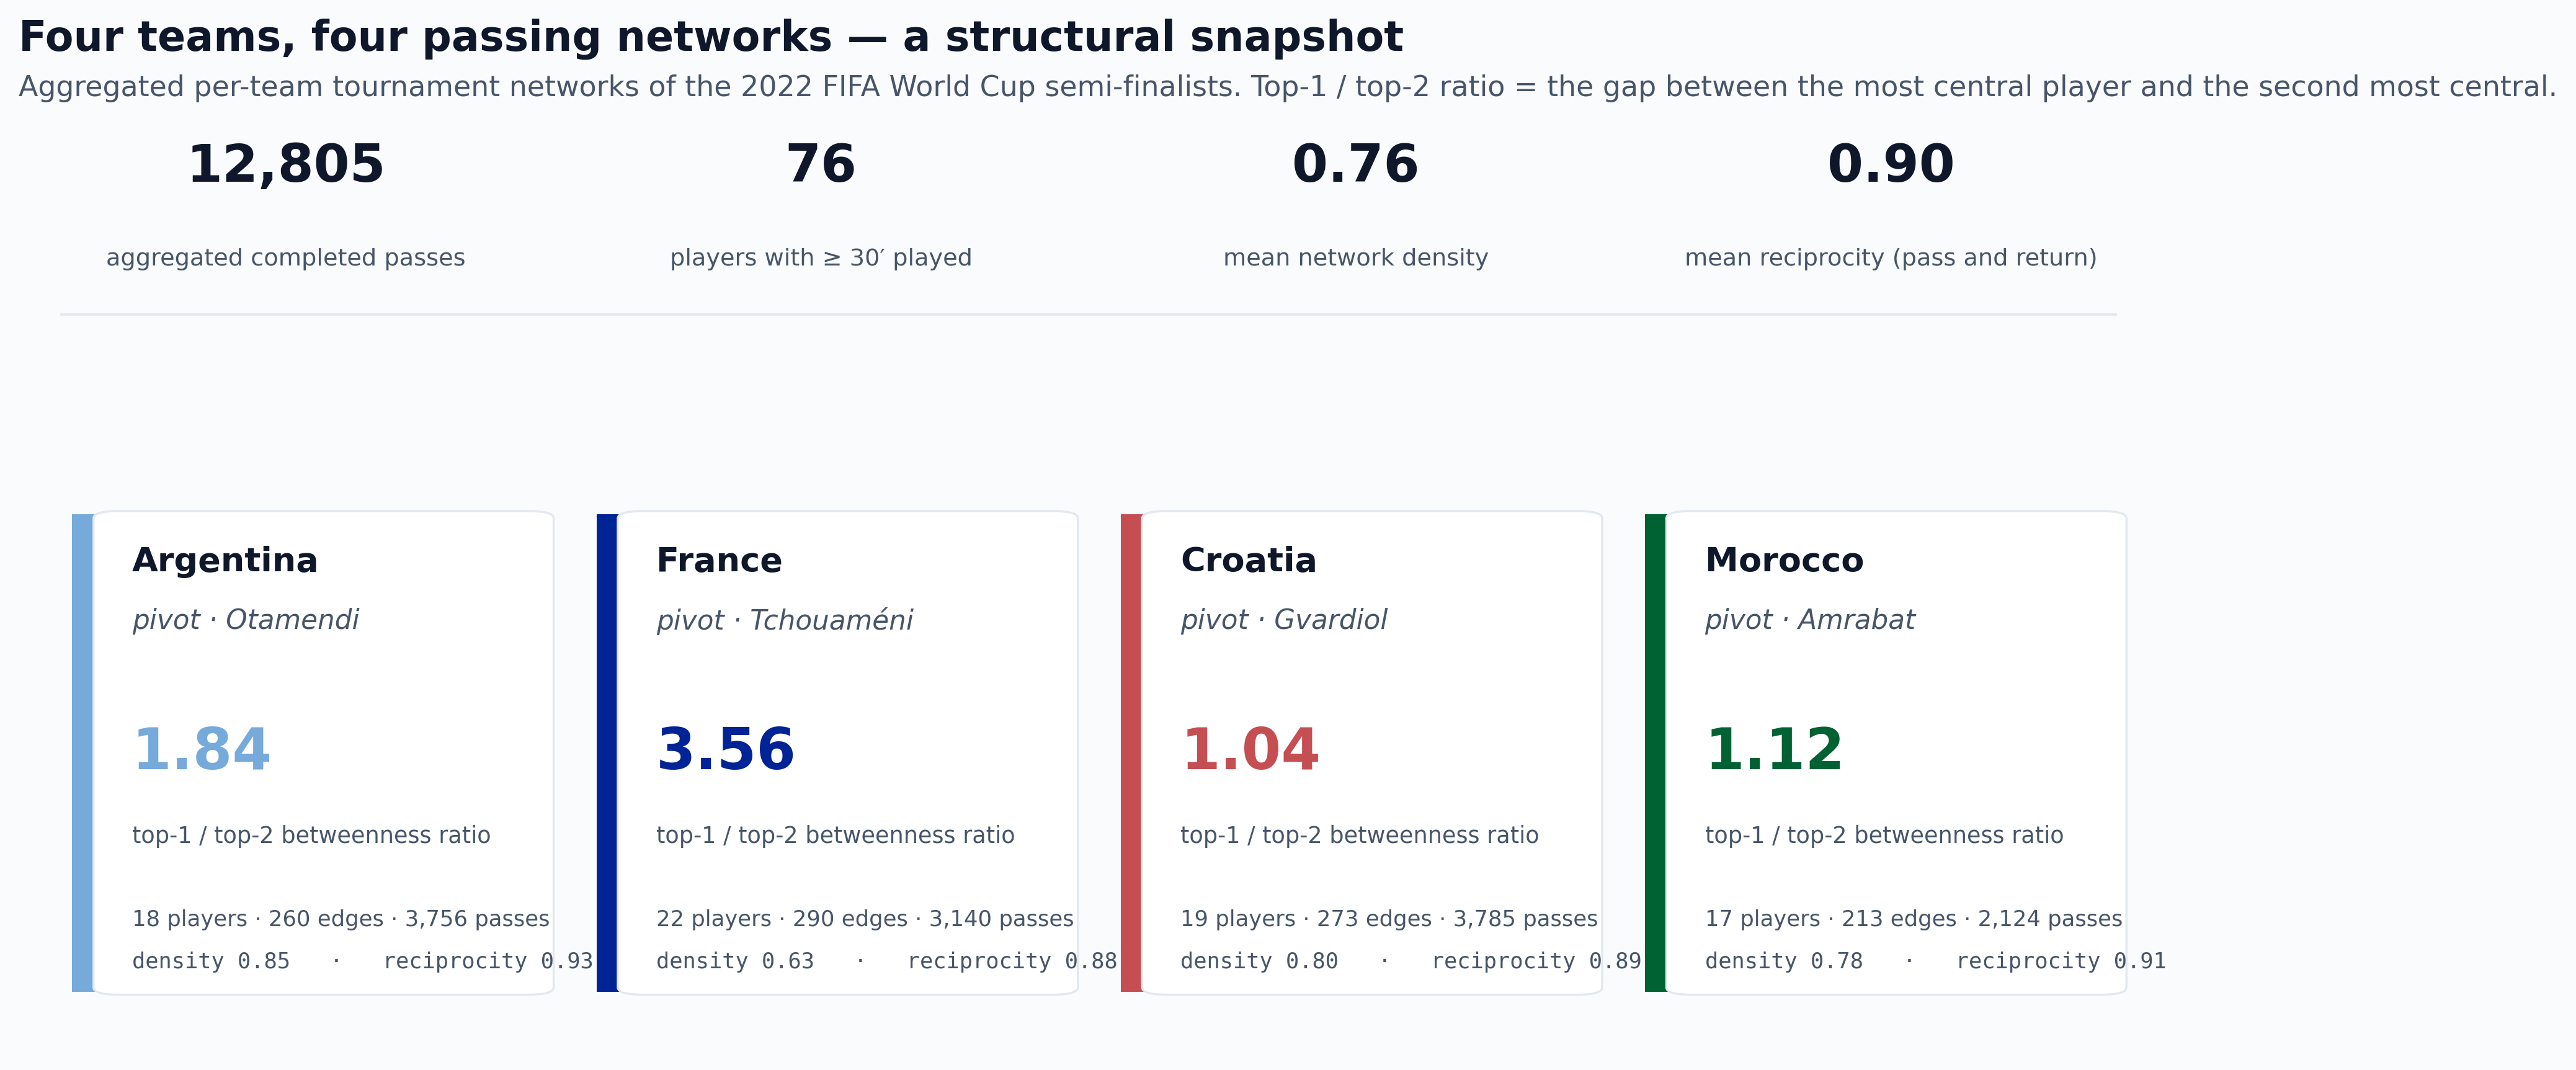

In [32]:
# A visual summary of the four-team setup
fig = plt.figure(figsize=FIG["wide"], facecolor=BG)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 2.6],
                      left=0.05, right=0.97, top=0.93, bottom=0.06,
                      hspace=0.35)

# --- Title and subtitle directly on the figure
fig.text(0.05, 0.985, "Four teams, four passing networks — a structural snapshot",
         ha="left", va="top", fontsize=TEXT["fig_title"],
         fontweight="semibold", color=INK)
fig.text(0.05, 0.935,
         "Aggregated per-team tournament networks of the 2022 FIFA World Cup semi-finalists. "
         "Top-1 / top-2 ratio = the gap between the most central player and the second most central.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT)

# --- KPI strip: aggregate totals across the four teams
ax_kpi = fig.add_subplot(gs[0])
total_passes = int(setup_df["total passes"].sum())
total_players = int(setup_df["n"].sum())
mean_density = setup_df["density"].mean()
mean_reciprocity = setup_df["reciprocity"].mean()
add_kpi_strip(ax_kpi, [
    (f"{total_passes:,}",         "aggregated completed passes"),
    (f"{total_players}",          "players with \u2265 30\u2032 played"),
    (f"{mean_density:.2f}",       "mean network density"),
    (f"{mean_reciprocity:.2f}",   "mean reciprocity (pass and return)"),
])

# --- Per-team mini-cards
ax_cards = fig.add_subplot(gs[1]); ax_cards.set_axis_off()
ax_cards.set_xlim(0, 1); ax_cards.set_ylim(0, 1)
for i, row in setup_df.iterrows():
    x0 = 0.025 + i * 0.245; x1 = x0 + 0.22
    team = row["team"]; color = TEAM_COLORS[team]
    # Left coloured stripe
    ax_cards.add_patch(Rectangle((x0, 0.10), 0.012, 0.80,
                                 fc=color, ec="none", clip_on=False))
    # Card body
    ax_cards.add_patch(FancyBboxPatch((x0 + 0.015, 0.10), 0.205, 0.80,
        boxstyle="round,pad=0.005,rounding_size=0.012",
        fc="white", ec=MUTED, lw=0.8, clip_on=False))
    # Team name
    team_it = {"Argentina":"Argentina","France":"France","Croatia":"Croatia","Morocco":"Morocco"}[team]
    ax_cards.text(x0 + 0.028, 0.82, team_it, ha="left", va="center",
                  fontsize=13, fontweight="semibold", color=INK)
    # Pivot
    ax_cards.text(x0 + 0.028, 0.72, f"pivot \u00b7 {row['pivot']}", ha="left",
                  va="center", fontsize=10.5, color=INK_SOFT, fontstyle="italic")
    # Top1/top2 ratio - the highlighted number
    ax_cards.text(x0 + 0.028, 0.50, f"{row['top1/top2']:.2f}", ha="left",
                  va="center", fontsize=22, fontweight="semibold", color=color)
    ax_cards.text(x0 + 0.028, 0.36, "top-1 / top-2 betweenness ratio",
                  ha="left", va="center", fontsize=8.8, color=INK_SOFT)
    ax_cards.text(x0 + 0.028, 0.22,
                  f"{row['n']} players \u00b7 {row['edges']} edges \u00b7 {int(row['total passes']):,} passes",
                  ha="left", va="center", fontsize=8.5, color=INK_SOFT)
    ax_cards.text(x0 + 0.028, 0.15,
                  f"density {row['density']:.2f}   \u00b7   reciprocity {row['reciprocity']:.2f}",
                  ha="left", va="center", fontsize=8.5, color=INK_SOFT,
                  family="monospace")
plt.show()


**What we learned.**

- All four networks are **dense** (density 0.63–0.85) and **highly reciprocal** (0.88–0.93): in practice, near-complete graphs in which almost every pass is reciprocated. This is interesting in itself: at the aggregated-tournament level, every outfield player of a team ends up passing the ball to almost every teammate at least once. It is a structural feature of these networks, and it will shape our metric choices.
- **Morocco** is the outlier by volume: just 2,124 total passes against the 3,100–3,800 of the other three. Consistent with a less possession-oriented, more direct style of play. **France**, at the opposite end, has the widest rotation (22 players over 30′ played in the tournament), which mechanically lowers its density (0.63): more players = more possible pairs = lower density for the same number of passes.
- The **top-1 / top-2 ratio** varies by more than threefold across the four teams: from **1.04** (Croatia — Gvardiol and Modrić essentially tied) to **3.56** (France — Tchouaméni clearly above everyone). This variability is excellent news: it means the four teams genuinely explore different styles of play, from "multi-centred" to "single-centred" networks, and this gives enough range to test the correlation between dominance and fragility.
- Croatia's case is a small *structural tie*: in our construction Gvardiol ranks slightly ahead of Modrić, but the ratio of 1.04 says they are practically indistinguishable. In the rest of the notebook we treat Gvardiol as "the" Croatian pivot for consistency with the procedure, but it is important to keep in mind that the same analysis with Modrić in place of the defender would give almost identical results.
- *Hypothesis to be tested later:* the top-1/top-2 ratio should predict how much each team suffers when we remove its pivot. Teams with a ratio near 1 should be robust (they have a ready replacement); teams with a high ratio should be fragile (no one does what the pivot does).


---
## 2. How to measure damage — why $S(q)$ is not enough here

The standard robustness metric, seen in NS07, is

$$ S(q) = \frac{\text{size of the LCC after removing a fraction } q}{N}, $$

where LCC is the *largest connected component* and $N$ is the initial number of nodes. It is the metric with which Albert, Jeong and Barabási showed that scale-free networks are robust to random errors and fragile to targeted attacks. It works perfectly on the sparse, large networks it was designed for, where removing enough hubs fragments the graph into many separate islands.

On our networks it **does not work well**, and the reason is structural. They are too dense (density 0.63–0.85, with reciprocity above 0.88): **removing a single node almost never breaks the main connected component**. We verified this empirically on more than 800 trial removals: in practice $S(1/N)$ always stays very close to 1, so the metric does not discriminate between destructive and harmless removals. Every player "brings down the same 5–10%" of the LCC, simply because removing a node from a near-complete network still leaves all the others connected to each other.

We therefore need metrics that capture the **qualitative degradation of the network before it even breaks**: not *did it break, yes or no?* but *how much less efficient did it become?*. We use two, complementary to each other:

- **Average path length** on the LCC, using `1/weight` as distance, so that frequent passes correspond to short routes. It is sensitive to the *worst peak*: if even a single pair of players now has to take a long detour to exchange the ball, the index rises.
- **Global efficiency** $E = \frac{1}{n(n-1)}\sum_{i \neq j} \frac{1}{d_{ij}}$ — the mean of the inverse distances over all reachable pairs (Latora & Marchiori 2001). By construction, it gives more weight to *nearby* pairs and less to *distant* ones, so it captures the *average tone* of the network rather than the peak. The lower it is, the more slowly the ball circulates overall.

The two metrics look at the same phenomenon from two different angles: average path length is dominated by the worst-off pairs, efficiency by the best-off pairs. In a *heavily* damaged network both move in the same direction; in a *locally* damaged network they move by different amounts, and the ratio between the two changes is informative. We will use exactly this complementarity to read each individual team's case.

In both cases we report the **relative damage** with respect to the baseline, choosing the sign so that *a positive value always means "worse than before"*: for average path length we use $(\text{post} - \text{pre})/\text{pre}$, because longer paths are worse; for efficiency we use $(\text{pre} - \text{post})/\text{pre}$, because lower efficiency is worse.


In [33]:
baseline_rows = []
for team in TEAMS:
    G = graphs[team]
    baseline_rows.append({
        "team":             team,
        "avg path length":  avg_path_length(G),
        "efficiency":       efficiency(G),
    })
baseline_df = pd.DataFrame(baseline_rows).set_index("team")
print(baseline_df.round(3).to_string())


           avg path length  efficiency
team                                  
Argentina            0.078      19.073
France               0.171      11.010
Croatia              0.108      16.671
Morocco              0.151      10.987


**What we learned.**

- **Argentina** has the shortest paths (0.078) and the highest efficiency (19.07): a dense, well-connected possession network in which the ball needs, on average, fewer (weighted) passes to get from anyone to anyone. Consistent with the high passing volume and with a flow that, while having a clear hub in Otamendi, stays well distributed.
- **Croatia** is second on both metrics (paths 0.108, efficiency 16.67): a network almost as efficient as Argentina's, though without a single hub that shortens the paths to the maximum — a foreshadowing of the fact that Croatia has no single structural *funnel*.
- **France** has the **longest** paths of the four (0.171), despite a good passing volume: the wide rotation (22 players) and the lower density (0.63) mechanically lengthen the optimal weighted paths — more players and lower density mean that, on average, the ball has to make a few more passes to connect any two teammates.
- **Morocco** has the **lowest** efficiency (10.99) and the second-longest paths (0.151): consistent with a less possession-based style (just 2,124 passes, fewer exchanges, more strained optimal paths).
- The two metrics **do not rank the teams the same way**: by path length the order is Argentina < Croatia < Morocco < France, by efficiency it is Argentina > Croatia > France > Morocco. France is the emblematic case — the longest paths but efficiency above Morocco — because its *nearby* pairs stay well connected (high average tone) while a few *distant* pairs pay a long route (worst peak). This is exactly the complementarity described above: average path length is dominated by the worst pairs, efficiency by the bulk of the nearby pairs.
- These four values (across two metrics) are the *baseline* against which we will compare the damage of removing a player. The rest of the notebook is the story of *how much these numbers worsen*.


---
## 3. Removing one player — pivot vs random player

For each team we repeat the targeted-attack experiment from Lecture 7, but in a mini version and against an appropriate null model. The logic is the same as a *permutation test*:

| | What we remove | How many times |
|---|---|---|
| **Targeted** | the top-1 player by weighted betweenness (the pivot) | 1 |
| **Random** | a random outfield player (excluding the goalkeeper and the pivot) | $N = 200$ |

The *null model* here is "if we removed any non-pivot player, how much damage would we expect?". The 200 random removals reconstruct the distribution of this "typical damage". By comparing the single targeted damage with this distribution, we can say whether removing the pivot is actually more damaging or whether it falls within what one would expect by chance.

We exclude the goalkeeper from the random removals for two reasons. First, the goalkeeper has a very particular structural position (it is essentially a one-directional *spoke*: it receives back-passes and launches forward), and its removal tends to be destructive for reasons that have nothing to do with centrality in the sense we care about here. Second, no coach *removes* the goalkeeper in a tactical sense, whereas they regularly remove defenders and midfielders, so the random pool also reflects a notion of footballing plausibility.

For each team × metric combination, we turn the targeted damage into a **z-score** with respect to the distribution of the 200 random removals:

$$ z = \frac{\text{targeted damage} - \text{mean of random damages}}{\text{standard deviation of random damages}}. $$

A $z$ of +1 means "the targeted damage is one standard deviation above the mean of random damages" (not very exceptional); a $z$ of +4 means "the targeted damage is four standard deviations above the mean" (exceptional: under a Gaussian assumption, fewer than 0.01% of random removals would reach this level). We also report the **one-tailed p-value**, that is, the fraction of random removals that reach or exceed the damage of removing the pivot: it is the *non-parametric* version of the z-score, it does not assume a Gaussian distribution and is slightly more conservative for small samples. Note: the significance stars in the figure refer to this non-parametric p, not to the z-score. When the null distribution is multimodal (as for Croatia), a very low p can coexist with a modest z — they signal different things, and to judge relative *robustness* across teams we look at the mean z-score, not the stars.


In [34]:
metrics = {"avg_path_length": avg_path_length, "efficiency": efficiency}

rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G); pivot = max(btw, key=btw.get)
    pre = {m: f(G) for m, f in metrics.items()}

    # Targeted
    Gt = G.copy(); Gt.remove_node(pivot)
    post = {m: f(Gt) for m, f in metrics.items()}
    for m in metrics:
        rows.append({"team": team, "mode": "targeted", "realisation": 0,
                     "metric": m,
                     "damage": relative_damage(pre[m], post[m], m)})

    # Random null
    rng = np.random.default_rng(RANDOM_SEED)
    outfield = [n for n in G.nodes() if G.nodes[n].get("line") != "GK" and n != pivot]
    for r in range(N_RANDOM):
        n_remove = rng.choice(outfield)
        Gr = G.copy(); Gr.remove_node(n_remove)
        post = {m: f(Gr) for m, f in metrics.items()}
        for m in metrics:
            rows.append({"team": team, "mode": "random", "realisation": r,
                         "metric": m,
                         "damage": relative_damage(pre[m], post[m], m)})

df = pd.DataFrame(rows)

# Summary table.
summary = []
for team in TEAMS:
    for m in metrics:
        sub = df[(df.team == team) & (df.metric == m)]
        t = sub[sub["mode"] == "targeted"]["damage"].iloc[0]
        rvs = sub[sub["mode"] == "random"]["damage"].dropna().values
        rmean, rstd = rvs.mean(), rvs.std(ddof=1)
        z = (t - rmean) / rstd if rstd > 0 else float("nan")
        p = float(np.mean(rvs >= t))
        summary.append({"team": team, "metric": m,
                        "targeted": round(t, 4),
                        "random mean": round(rmean, 4),
                        "random std":  round(rstd, 4),
                        "z": round(z, 2), "p": round(p, 3)})
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


     team          metric  targeted  random mean  random std    z    p
Argentina avg_path_length    0.3030       0.0155      0.0616 4.66 0.00
Argentina      efficiency    0.2127       0.0059      0.0589 3.51 0.00
   France avg_path_length    0.2425       0.0097      0.0489 4.76 0.00
   France      efficiency    0.1689       0.0028      0.0535 3.11 0.00
  Croatia avg_path_length    0.1024       0.0116      0.0636 1.43 0.05
  Croatia      efficiency    0.1250      -0.0016      0.0724 1.75 0.00
  Morocco avg_path_length    0.1745       0.0315      0.0726 1.97 0.09
  Morocco      efficiency    0.1280       0.0102      0.0710 1.66 0.09


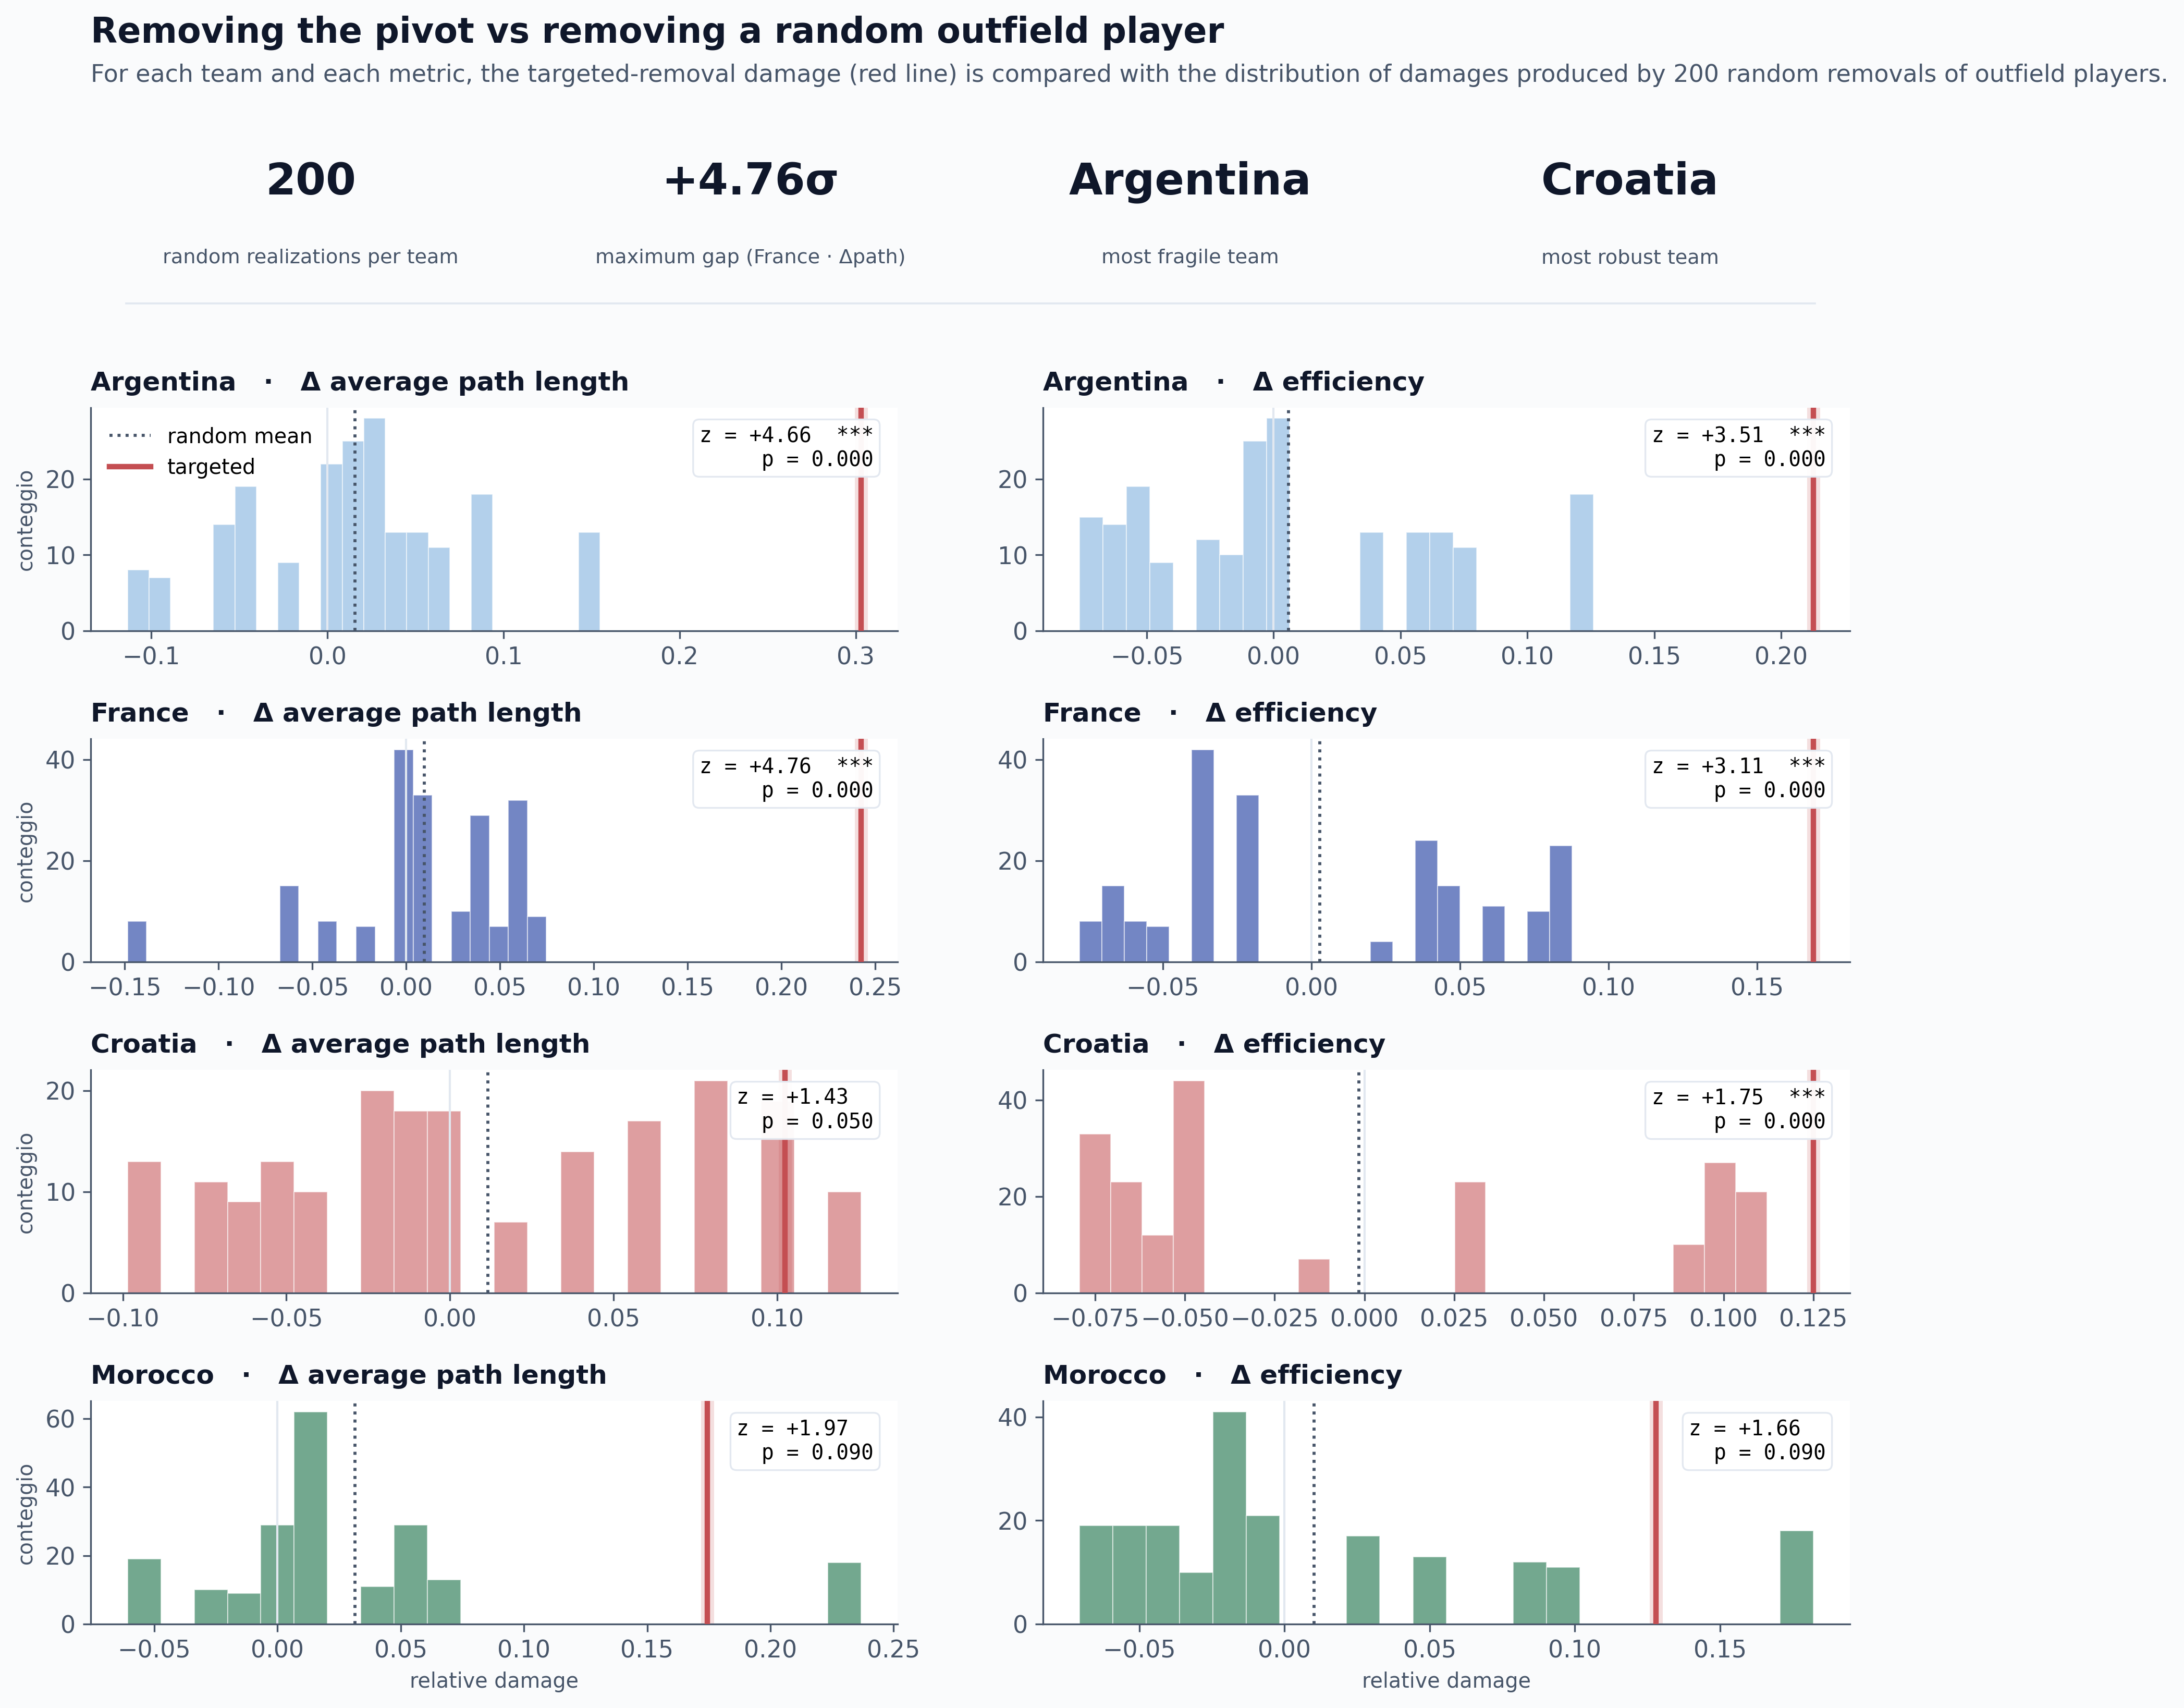

In [35]:
# Hero figure for §3: KPI band + 4×2 grid of histograms with targeted overlay.
_team_it_map = {"Argentina":"Argentina","France":"France","Croatia":"Croatia","Morocco":"Morocco"}
fig = plt.figure(figsize=FIG["grid"], facecolor=BG)
gs = fig.add_gridspec(nrows=5, ncols=2, height_ratios=[0.85, 1, 1, 1, 1],
                      left=0.07, right=0.97, top=0.93, bottom=0.05,
                      hspace=0.50, wspace=0.18)

fig.text(0.07, 0.985, "Removing the pivot vs removing a random outfield player",
         ha="left", va="top", fontsize=TEXT["fig_title"], fontweight="semibold",
         color=INK)
fig.text(0.07, 0.957,
         "For each team and each metric, the targeted-removal damage (red line) is compared "
         "with the distribution of damages produced by 200 random removals of outfield players.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT)

# KPI strip across the top
ax_kpi = fig.add_subplot(gs[0, :])
ranked = summary_df.groupby("team")["z"].mean().sort_values(ascending=False)
most_fragile, least_fragile = ranked.index[0], ranked.index[-1]
max_z = summary_df["z"].max()
mean_z = summary_df["z"].mean()
add_kpi_strip(ax_kpi, [
    (f"{N_RANDOM}",                     "random realizations per team"),
    (f"{max_z:+.2f}σ",                  f"maximum gap (France \u00b7 \u0394path)"),
    (_team_it_map.get(most_fragile, most_fragile),    "most fragile team"),
    (_team_it_map.get(least_fragile, least_fragile),  "most robust team"),
])

# The 4×2 grid
for i, team in enumerate(TEAMS):
    for j, metric in enumerate(["avg_path_length", "efficiency"]):
        ax = fig.add_subplot(gs[i + 1, j])
        sub = df[(df.team == team) & (df.metric == metric)]
        rand_vals = sub[sub["mode"] == "random"]["damage"].dropna().values
        targ_val  = sub[sub["mode"] == "targeted"]["damage"].iloc[0]
        # Histogram of random null
        ax.hist(rand_vals, bins=22, color=TEAM_COLORS[team], alpha=0.55,
                edgecolor="white", linewidth=0.5)
        ax.axvline(0, color=MUTED, lw=1.0, zorder=1)
        # Random mean
        ax.axvline(rand_vals.mean(), color=INK_SOFT, linestyle=":",
                   linewidth=1.4, label="random mean")
        # Targeted: three-pass glow effect for emphasis
        ax.axvline(targ_val, color=HIGHLIGHT, linewidth=6, alpha=0.18, zorder=2)
        ax.axvline(targ_val, color=HIGHLIGHT, linewidth=2.5, zorder=3,
                   label="targeted")
        # z and p chip in the corner
        z = (targ_val - rand_vals.mean()) / rand_vals.std(ddof=1)
        p_val = float(np.mean(rand_vals >= targ_val))
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
        ax.text(0.97, 0.92, f"z = {z:+.2f}  {sig}\np = {p_val:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=TEXT["annotation"], family="monospace",
                bbox=dict(boxstyle="round,pad=0.30", fc="white", ec=MUTED,
                          lw=0.8, alpha=0.96))
        # Title (panel-style)
        nice_metric = {"avg_path_length": "\u0394 average path length",
                       "efficiency": "\u0394 efficiency"}[metric]
        team_it = {"Argentina":"Argentina","France":"France","Croatia":"Croatia","Morocco":"Morocco"}[team]
        style_panel(ax, title=f"{team_it}   ·   {nice_metric}", subtitle=None)
        ax.set_xlabel("relative damage" if i == 3 else "",
                      fontsize=TEXT["annotation"], color=INK_SOFT)
        ax.set_ylabel("conteggio" if j == 0 else "",
                      fontsize=TEXT["annotation"], color=INK_SOFT)
        if i == 0 and j == 0:
            ax.legend(loc="upper left", frameon=False,
                      fontsize=TEXT["annotation"])

plt.show()


**What we learned.**

- For all four teams, **removing the pivot does more damage than the average of the random removals**, on both metrics. The top-1 player by betweenness really is doing something the others do not. This confirms our base hypothesis: weighted betweenness, although defined on an abstract graph, identifies players who play a structurally distinct role in the passing network.
- **Argentina** is the team that suffers the most: $z = +4.66$ on the Δ-average-path-length and $z = +3.51$ on the Δ-efficiency. Otamendi is structurally irreplaceable — removing him produces damage four times the standard deviation of the random removals. More than 99.5% of the 200 control removals cause less damage than removing Otamendi on both metrics.
- **France** is right behind on both metrics ($z = +4.76$ on Δ-path; $z = +3.11$ on Δ-efficiency). Removing Tchouaméni is practically impossible to replicate by chance. On the Δ-path France is even *slightly more extreme* than Argentina, but on Δ-efficiency Argentina overtakes it — we return to this difference in the paragraph below.
- **Croatia** is the most robust of the four: $z = +1.43$ on Δ-path and $z = +1.75$ on Δ-efficiency. Removing Gvardiol (or, equivalently, Modrić — they are practically tied) looks like a serious but not catastrophic loss, well within the envelope of the random removals. The team has redundancy, consistent with a midfield of three near-interchangeable pivots (Modrić, Brozović, Kovačić).
- **Morocco** sits in the middle ($z \approx +1.7$ on both metrics): an identifiable pivot, but not as dominant as those of Argentina and France. The interesting thing is that, of the four, it is the team where the pivot and the second (Amrabat and Hakimi) are the most different from each other by role — a defensive midfielder and an attacking full-back — yet the structural dominance remains modest.
- A small subtlety worth noting: Argentina and France have practically identical *Δ-path* (z 4.66 vs 4.76), but Argentina has noticeably higher *Δ-efficiency* (z 3.51 vs 3.11). In network terms, this means that removing Otamendi damages not only the most distant pairs (paths) but also, significantly, the nearby ones (efficiency), whereas removing Tchouaméni damages mainly the most distant pairs. Otamendi is therefore a slightly more *pervasive* pivot than Tchouaméni: his role is felt everywhere, not just on the longest connections. This is also a preview of a result we will find later: Argentina will be the only outlier from the regression line, and the reason will be that the top-1/top-2 ratio of 1.84 underestimates how structurally central Otamendi is.


---
## 4. Removing several players — one, two, three

Removing a single player tells us how much the team depends on that one name. But a team can be *fragile on a single name* (remove it and it collapses, but the second is less critical) or *fragile in depth* (the top three are all hubs). The classic experiment by Albert, Jeong and Barabási (2000) gives us the key to distinguish the two cases: at each step we **recompute betweenness on the remaining graph** and remove the new top-1. The cumulative-damage curve is called, in the literature, an *attack curve*, and its shape reveals how many effective hubs the network has.

**A note on the word "hub".** In the original Albert-Jeong-Barabási paper a *hub* is a node of high **degree** (many connections), and the classic attack removes precisely the highest-degree nodes. Here, instead, we remove the highest-**betweenness** nodes, because our networks are so dense (density 0.63–0.85, reciprocity above 0.88) that degree is nearly saturated for everyone and no longer discriminates who matters from who does not. It is weighted betweenness that separates the players, because it identifies who acts as the *flow hub* (the playmaker) and not who simply has more passes. So when we say "hub" in this section we mean a **flow hub**, not a degree hub: a node that concentrates a very high share of the optimal paths, just as a degree hub concentrates the connections in a scale-free network. The interesting point is precisely that the Albert-Jeong-Barabási pattern — robust to random errors, fragile to targeted attacks — does not depend on the *type* of concentrated resource (degree there, flow here) but on its **heterogeneity**.

It is important that betweenness is *recomputed at each step* and not computed only once at the beginning. This is a common mistake in the applied literature: if you compute the initial top-3 and remove them all at once, you are measuring something different — you are measuring how much the three nodes that *were* the top-3 before removing anyone mattered. By recomputing, instead, we faithfully simulate the scenario "we always remove the most critical node *at the current moment*", which is the version consistent with the Albert-Jeong-Barabási idea of an *attack*.

We stop after three removals for two practical reasons. First, at later steps the average path length becomes noisy: removing the fourth or fifth node from a network that has already lost three brings the network close to the fragmentation threshold and the numbers become dominated by *which* subgraph is left, not by *how much* we have damaged it. Second, from a footballing point of view, "removing the top three by betweenness" corresponds roughly to *a trio of injuries in the team's strategic core*, a realistic scenario for a World Cup; "removing the top six" is an apocalyptic scenario that falls outside sensible analysis.

Alongside each targeted curve we place the corresponding **random-removal curve** — three nodes removed at random one after another (always excluding pivot and goalkeeper), averaged over the 200 realizations — as an immediate visual reference (dashed line). We do not redo the z-score analysis from §3: here the point is the qualitative *shape* of the curve, not the significance of the difference.


In [36]:
# ---- Progressive targeted attack: recompute betweenness and remove the new top-1 at each step.
prog_rows = []
for team in TEAMS:
    G_curr = graphs[team].copy()
    baseline = {m: f(G_curr) for m, f in metrics.items()}
    removed = []
    for step in range(4):
        post = {m: f(G_curr) for m, f in metrics.items()}
        prog_rows.append({
            "team":   team,
            "step":   step,
            "removed so far": ", ".join(short(n) for n in removed) or "\u2014",
            "\u0394 avg path length": relative_damage(baseline["avg_path_length"],
                                                  post["avg_path_length"],
                                                  "avg_path_length"),
            "\u0394 efficiency":       relative_damage(baseline["efficiency"],
                                                  post["efficiency"],
                                                  "efficiency"),
        })
        if step < 3:
            btw = weighted_betweenness(G_curr)
            nxt = max(btw, key=btw.get)
            removed.append(nxt)
            G_curr.remove_node(nxt)

prog_df = pd.DataFrame(prog_rows)

# ---- Random reference: cumulative removal of 3 outfield nodes (excluding pivot and
#      goalkeeper)
rand_prog_rows = []
for team in TEAMS:
    G0 = graphs[team]
    baseline = {m: f(G0) for m, f in metrics.items()}
    btw0 = weighted_betweenness(G0); pivot0 = max(btw0, key=btw0.get)
    outfield = [n for n in G0.nodes()
                if G0.nodes[n].get("line") != "GK" and n != pivot0]
    rng = np.random.default_rng(RANDOM_SEED)
    acc = {step: {m: [] for m in metrics} for step in (1, 2, 3)}
    for _ in range(N_RANDOM):
        chosen = rng.choice(outfield, size=3, replace=False)
        G_curr = G0.copy()
        for step, node in enumerate(chosen, start=1):
            G_curr.remove_node(node)
            for m, f in metrics.items():
                acc[step][m].append(relative_damage(baseline[m], f(G_curr), m))
    for step in (0, 1, 2, 3):
        if step == 0:
            apl_v = eff_v = 0.0
        else:
            apl_v = float(np.nanmean(acc[step]["avg_path_length"]))
            eff_v = float(np.nanmean(acc[step]["efficiency"]))
        rand_prog_rows.append({"team": team, "step": step,
                               "\u0394 avg path length": apl_v,
                               "\u0394 efficiency": eff_v})
rand_prog_df = pd.DataFrame(rand_prog_rows)

print(prog_df.round(3).to_string(index=False))


     team  step                removed so far  Δ avg path length  Δ efficiency
Argentina     0                             —              0.000         0.000
Argentina     1                      Otamendi              0.303         0.213
Argentina     2             Otamendi, De Paul              0.452         0.351
Argentina     3  Otamendi, De Paul, Fernandez              0.693         0.456
   France     0                             —              0.000         0.000
   France     1                    Tchouaméni              0.243         0.169
   France     2            Tchouaméni, Varane              0.465         0.279
   France     3 Tchouaméni, Varane, Griezmann              0.569         0.338
  Croatia     0                             —              0.000         0.000
  Croatia     1                      Gvardiol              0.102         0.125
  Croatia     2              Gvardiol, Modrić              0.264         0.268
  Croatia     3     Gvardiol, Modrić, Kovačić       

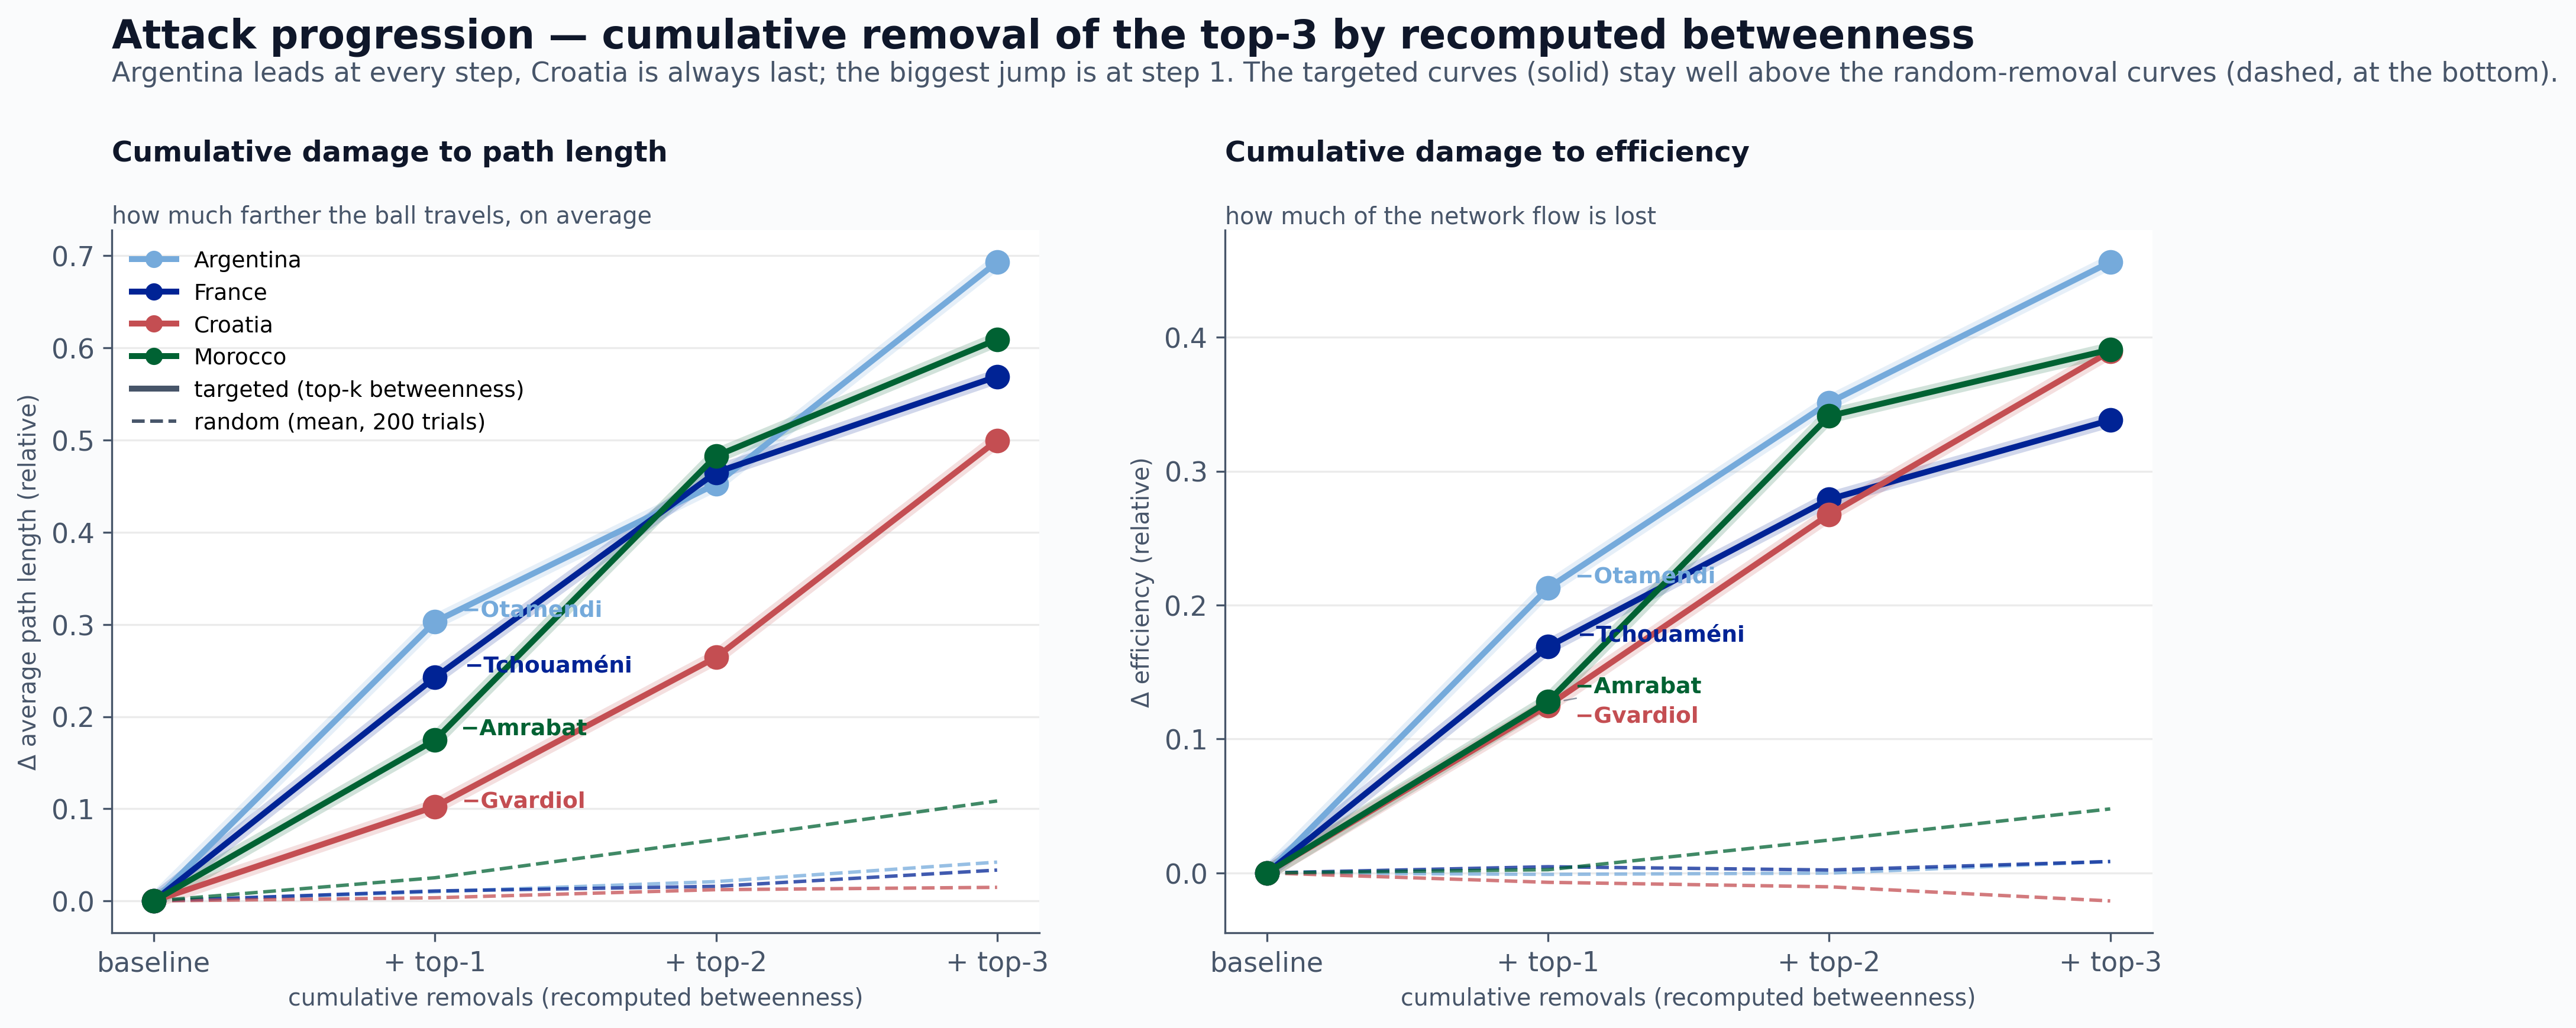

In [37]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text

_team_it = {"Argentina": "Argentina", "France": "France",
            "Croatia": "Croatia", "Morocco": "Morocco"}

fig, axes = plt.subplots(1, 2, figsize=FIG["wide"], facecolor=BG)

for ax, metric, ylabel, panel_title, panel_subtitle in zip(
    axes,
    ["\u0394 avg path length", "\u0394 efficiency"],
    ["\u0394 average path length (relative)", "\u0394 efficiency (relative)"],
    ["Cumulative damage to path length",
     "Cumulative damage to efficiency"],
    ["how much farther the ball travels, on average",
     "how much of the network flow is lost"],
):
    texts = []
    for team in TEAMS:
        sub = prog_df[prog_df.team == team]
        rnd = rand_prog_df[rand_prog_df.team == team]
        color = TEAM_COLORS[team]

        # Targeted curve: glow + solid line with markers
        ax.plot(sub.step, sub[metric], color=color, lw=6, alpha=0.18, zorder=1)
        ax.plot(sub.step, sub[metric], marker="o", markersize=9, linewidth=2.4,
                color=color, label=_team_it[team], zorder=3)

        # Random curve: thin dashed line, same colour, no markers
        ax.plot(rnd.step, rnd[metric], color=color, lw=1.4, ls="--",
                alpha=0.75, zorder=2)

        # Pivot label at step 1, on the targeted curve
        step1 = sub[sub.step == 1].iloc[0]
        t = ax.text(1.04, step1[metric], f"\u2212{step1['removed so far']}",
                    fontsize=TEXT["annotation"] - 0.5, color=color,
                    fontweight="semibold", zorder=5)
        texts.append(t)

    adjust_text(texts, ax=ax, only_move={"text": "y"},
                arrowprops=dict(arrowstyle="-", color=INK_SOFT, lw=0.6, alpha=0.6))

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["baseline", "+ top-1", "+ top-2", "+ top-3"])
    ax.set_ylabel(ylabel, fontsize=TEXT["annotation"], color=INK_SOFT)
    ax.set_xlabel("cumulative removals (recomputed betweenness)",
                  fontsize=TEXT["annotation"], color=INK_SOFT)
    ax.grid(True, alpha=0.25, axis="y")
    ax.set_title(panel_title, fontsize=TEXT["annotation"] + 2, color=INK,
                 pad=28, loc="left", fontweight="semibold")
    ax.text(0, 1.01, panel_subtitle, transform=ax.transAxes,
            fontsize=TEXT["annotation"], color=INK_SOFT, ha="left")

# Legend: teams + solid/dashed explanation
team_handles = [Line2D([0], [0], color=TEAM_COLORS[t], lw=2.4, marker="o",
                       label=_team_it[t]) for t in TEAMS]
style_handles = [
    Line2D([0], [0], color=INK_SOFT, lw=2.4, label="targeted (top-k betweenness)"),
    Line2D([0], [0], color=INK_SOFT, lw=1.4, ls="--",
           label="random (mean, 200 trials)"),
]
axes[0].legend(handles=team_handles + style_handles, loc="upper left",
               frameon=False, fontsize=TEXT["annotation"] - 0.5, ncol=1)

fig.suptitle("Attack progression \u2014 cumulative removal of the top-3 by recomputed betweenness",
             fontsize=TEXT["fig_title"], fontweight="bold", color=INK,
             x=0.06, ha="left", y=0.98)
fig.text(0.06, 0.92,
         "Argentina leads at every step, Croatia is always last; the biggest jump is at step 1. "
         "The targeted curves (solid) stay well above the random-removal curves (dashed, at the bottom).",
         fontsize=TEXT["fig_subtitle"], color=INK_SOFT, ha="left")

plt.subplots_adjust(left=0.06, right=0.98, top=0.78, bottom=0.12, wspace=0.20)
plt.show()


**What we learned.**

- The damage curves **always rise**, and the biggest jump is almost always between the baseline and step 1 (the pivot's effect). The behaviour at later steps, however, varies by team: **France** slows down after Tchouaméni (a sign that, with him gone, the midfield offers no other strong hubs), whereas **Argentina** and **Croatia** keep worsening markedly at steps 2 and 3 too, because they have more hubs in sequence to lose.
- **Argentina** has the largest damage **at every step**: from step 1 (Otamendi: $\Delta$path = 0.30, $\Delta$efficiency = 0.21) up to step 3 (Otamendi → De Paul → Fernández), where $\Delta$path reaches 0.69, the highest of the four. Consistent with §3: it has three very central players in a row, and removing them all flattens the network.
- **France** follows closely: Tchouaméni → Varane → Griezmann brings $\Delta$path to 0.57. Note that the *second* most critical node is a defender (Varane): once Tchouaméni is removed, the midfield offers no more strong hubs and the ball is forced to go through the defence.
- **Croatia** is the opposite case: minimal damage at step 1 and a more contained curve up to step 3 ($\Delta$path ≈ 0.50). Note the sequencing — Gvardiol, Modrić, Kovačić: a centre-back plus two midfielders, the classic Croatian vertical spine. Three near-interchangeable hubs cushion the loss of one, but not the loss of all three.
- **Morocco** starts below France at step 1 (Amrabat is less dominant than Tchouaméni), but its curve **crosses and overtakes** France's at steps 2 and 3 ($\Delta$path 0.61 vs 0.57; $\Delta$efficiency 0.39 vs 0.34): it is the smallest network of the four (17 nodes), so once the first hubs are removed the cumulative damage grows quickly. It still stays above Croatia at every step.
- The **random-removal** curves (dashed, at the bottom) stay clearly below the targeted ones at every step, for all four teams: the random mean at step 3 (three nodes removed at random) never exceeds the damage of the targeted removal of the pivot alone at step 1. It is Albert-Jeong-Barabási in mini form: networks with hubs are **robust if they lose a few nodes at random, but fragile if attacked precisely on the hubs**.


---
## 5. Putting it all together — does RQ1 predict RQ3?

At this point in the notebook we have, for each team, two measures obtained from independent experiments with different methodological rationales:

- **Dominance (from RQ1):** the top-1 / top-2 ratio of weighted betweenness, computed in §1. It measures *how far a single player is ahead of the second* in centrality. It is a static property of the whole graph.
- **Fragility (from RQ3):** the mean z-score over the two damage metrics from §3. It measures *how much the network suffers when we remove that single player*, relative to a null model of random removal. It is a dynamic property derived from a perturbation experiment.

The two measures are conceptually close but not identical. Dominance looks only at the top two rungs of the centrality ranking; fragility looks at the effect on the whole network of removing the first. If our story makes sense, the two measures must be **positively correlated**: the more dominant a team's pivot (high ratio), the more it should suffer when we remove it (high z-score). If they were not — if a team with a high ratio turned out robust, or one with a low ratio turned out fragile — we would have an internal contradiction between the two experiments, and we would have to figure out where the reading went wrong.

With only $n = 4$ teams, we are obviously not doing statistics in the classic sense: a correlation on four points has no meaningful p-value, and we could not distinguish a genuine correlation from a fortuitous alignment. What we are doing is an **internal consistency check** between two different analytical procedures applied to the same data: two different routes that, if the underlying theory is right, should arrive at the same place. It is the same kind of check done in physics when a constant is measured with two independent methods — not to discover something, but to verify that no systematic error slipped in along the way.

We report both Pearson (sensitive to magnitude) and Spearman (sensitive only to rank). Spearman is usually more informative with small $n$, because it is not swayed by a single outlier.


In [38]:
# Build the joint table.
fragility = summary_df.groupby("team")["z"].mean().rename("fragility z").to_frame()
dom = pd.DataFrame({"team": TEAMS,
                    "top1/top2": setup_df.set_index("team").loc[TEAMS, "top1/top2"].values
                   }).set_index("team")
joint = dom.join(fragility)
print(joint.round(2).to_string())

r,  _ = pearsonr(joint["top1/top2"], joint["fragility z"])
rs, _ = spearmanr(joint["top1/top2"], joint["fragility z"])
print(f"\nPearson  r = {r:+.2f}")
print(f"Spearman ρ = {rs:+.2f}   (n = 4 teams)")


           top1/top2  fragility z
team                             
Argentina       1.84         4.08
France          3.56         3.93
Croatia         1.04         1.59
Morocco         1.12         1.82

Pearson  r = +0.77
Spearman ρ = +0.80   (n = 4 teams)


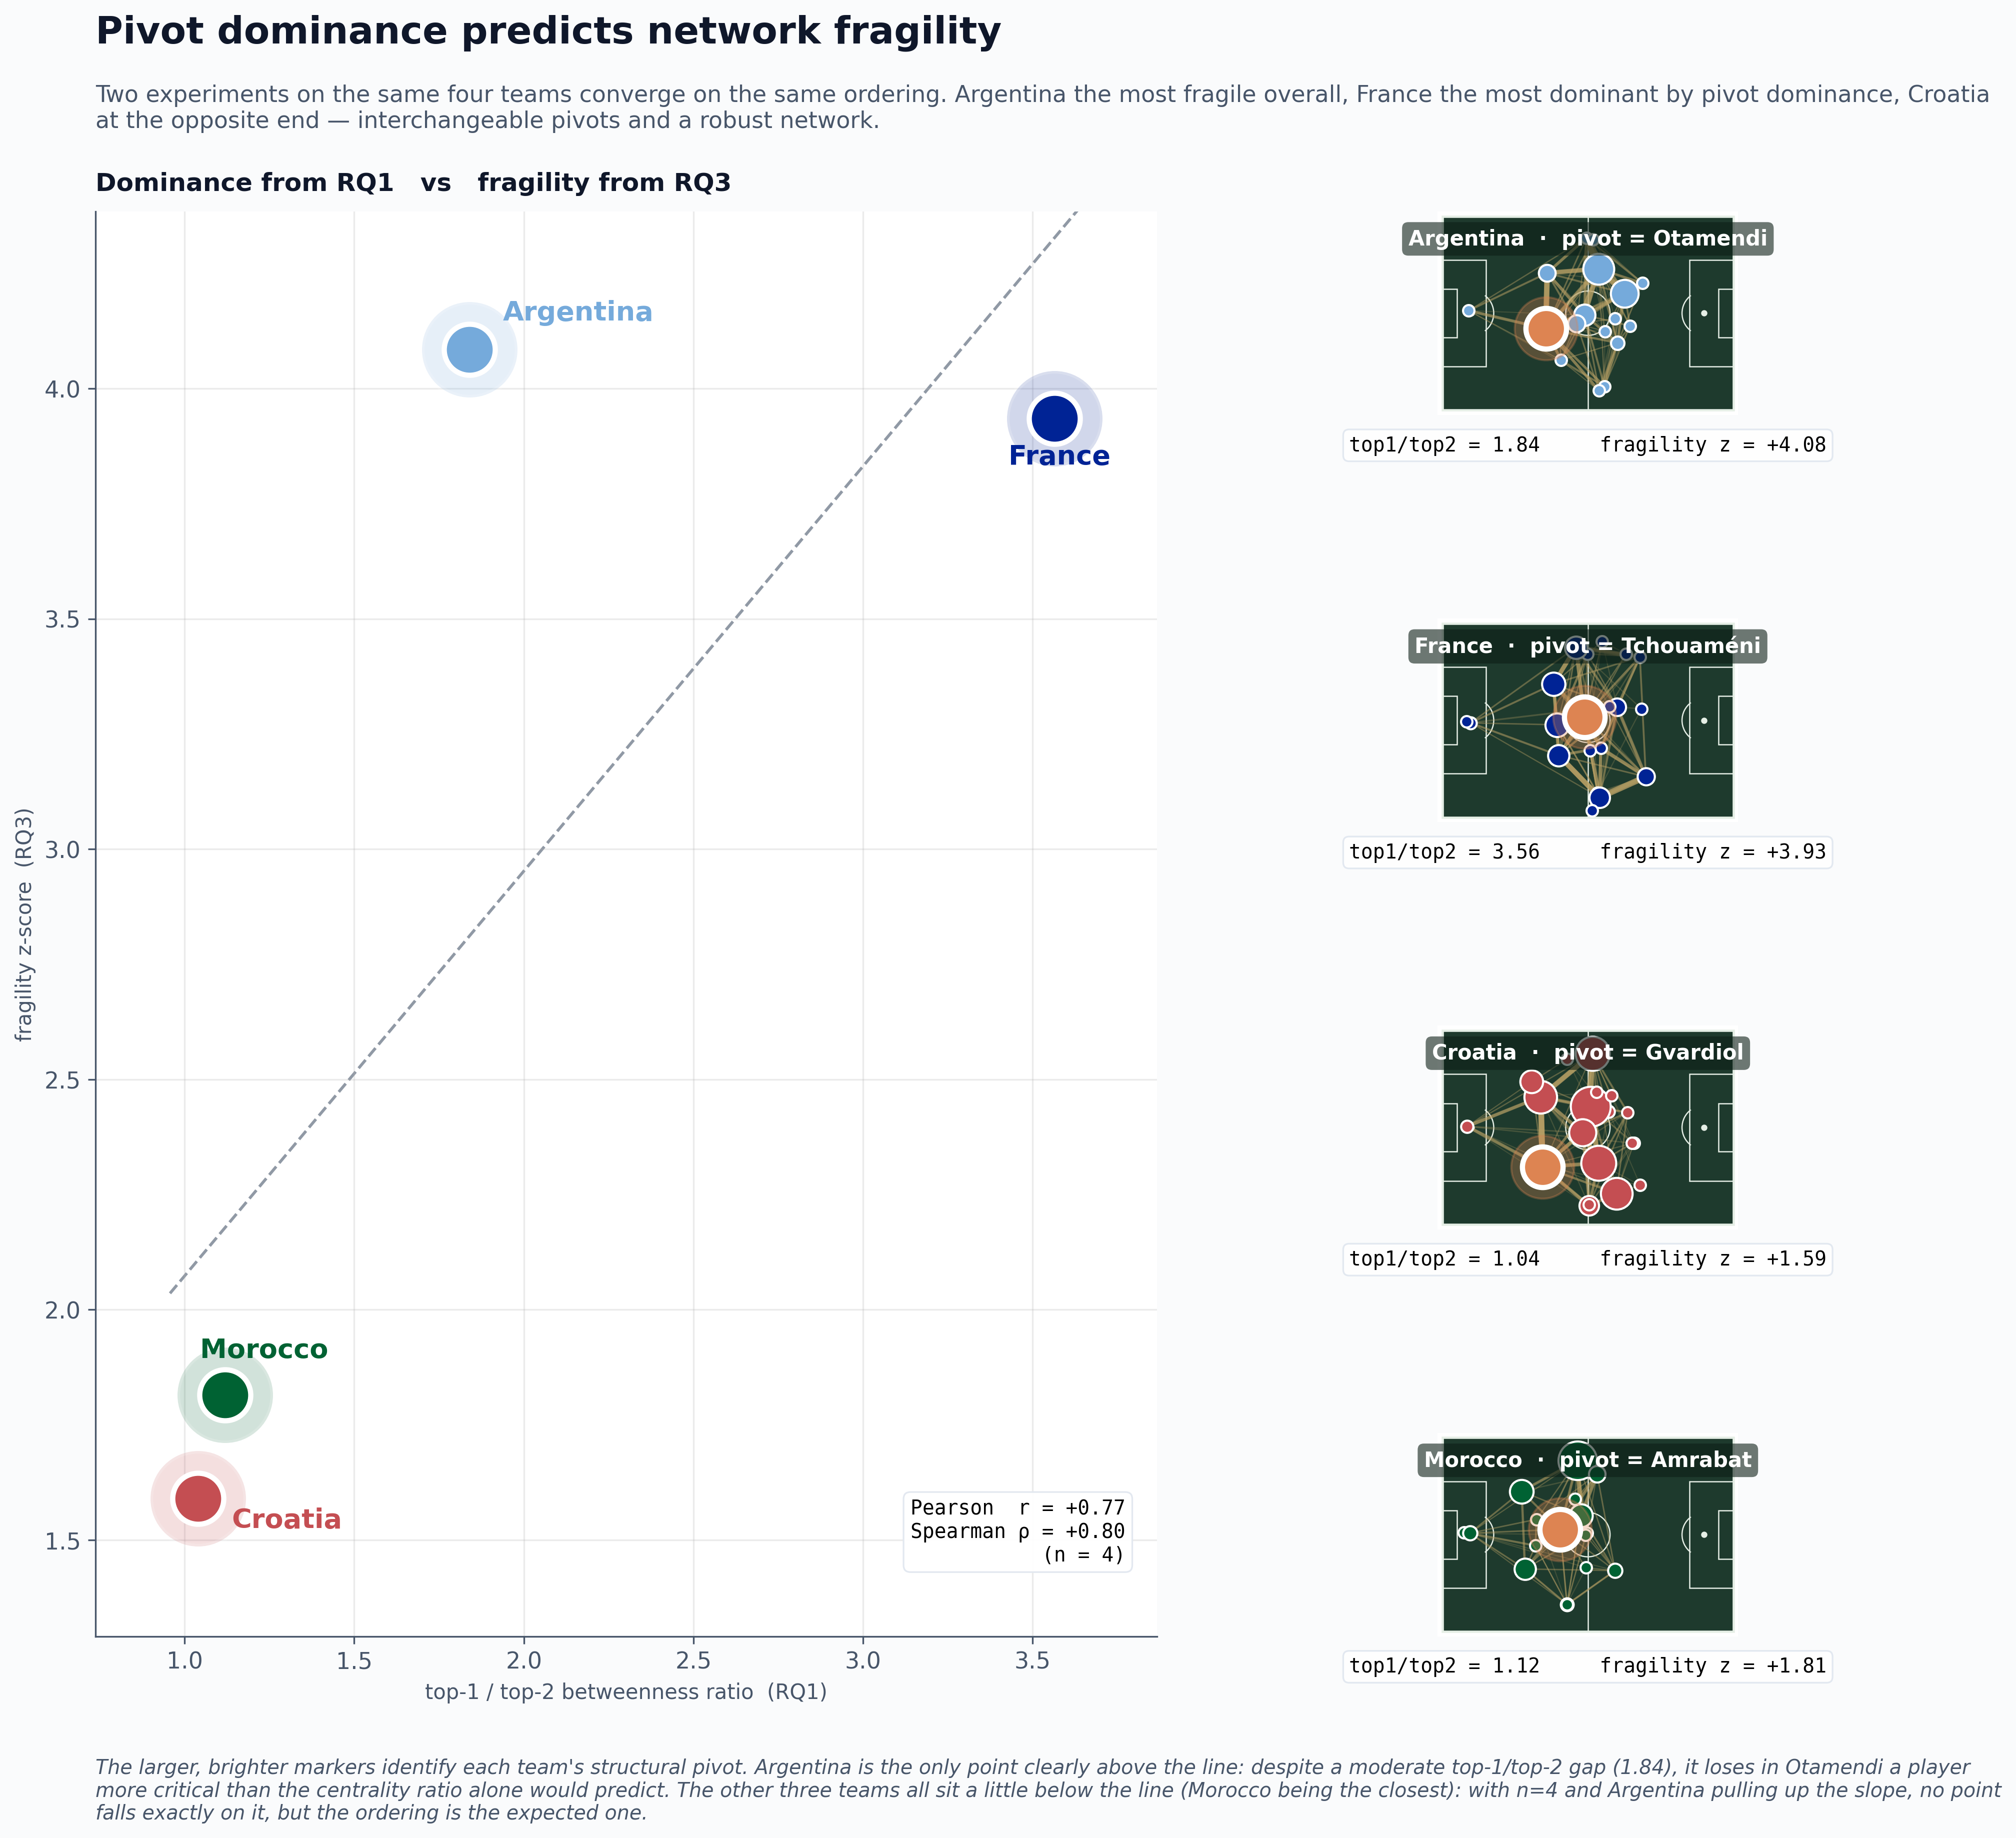

In [39]:
# Flagship composite: scatter + four pitch mini-cards on the side.

fig = plt.figure(figsize=FIG["flagship"], facecolor=BG)
gs = fig.add_gridspec(
    nrows=4, ncols=12,
    left=0.05, right=0.97, top=0.86, bottom=0.10,
    hspace=1.0, wspace=0.6,
)

# --- Banner -----------------------------------------------------------------
fig.text(0.05, 0.965,
         "Pivot dominance predicts network fragility",
         ha="left", va="top", fontsize=TEXT["fig_title"] + 2,
         fontweight="semibold", color=INK)
fig.text(0.05, 0.928,
         "Two experiments on the same four teams converge on the same ordering. "
         "Argentina the most fragile overall, France the most dominant by pivot dominance, "
         "Croatia at the opposite end — interchangeable pivots and a robust network.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT,
         wrap=True)

# --- Main panel: scatter ----------------------------------------------------
ax_main = fig.add_subplot(gs[0:4, 0:7])
# Best-fit line under data
slope, intercept = np.polyfit(joint["top1/top2"], joint["fragility z"], 1)
xs = np.linspace(joint["top1/top2"].min() * 0.92,
                 joint["top1/top2"].max() * 1.08, 50)
ax_main.plot(xs, slope * xs + intercept, "--", color=INK_SOFT, lw=1.4,
             alpha=0.6, zorder=1)
for team in TEAMS:
    x = joint.loc[team, "top1/top2"]
    y = joint.loc[team, "fragility z"]
    color = TEAM_COLORS[team]
    ax_main.scatter(x, y, s=2100, color=color, ec="white", lw=2.5,
                    alpha=0.18, zorder=2)
    ax_main.scatter(x, y, s=600, color=color, ec="white", lw=2.5, zorder=3)
    offsets = {"Argentina": (16, 14), "France": (-22, -22),
               "Croatia": (16, -14), "Morocco": (-12, 18)}
    ox, oy = offsets[team]
    team_it = {"Argentina":"Argentina","France":"France","Croatia":"Croatia","Morocco":"Morocco"}[team]
    ax_main.annotate(team_it, (x, y), xytext=(ox, oy), textcoords="offset points",
                     fontsize=13, fontweight="semibold", color=color)

# Correlation annotation in the corner
ax_main.text(0.97, 0.05,
             f"Pearson  r = {r:+.2f}\nSpearman ρ = {rs:+.2f}\n(n = 4)",
             transform=ax_main.transAxes, ha="right", va="bottom",
             fontsize=TEXT["annotation"], family="monospace",
             bbox=dict(boxstyle="round,pad=0.35", fc="white",
                       ec=MUTED, lw=0.8, alpha=0.96))

# Title for the panel
ax_main.set_title("Dominance from RQ1   vs   fragility from RQ3",
                  loc="left", pad=10,
                  fontsize=TEXT["panel_title"], fontweight="semibold", color=INK)
ax_main.set_xlabel("top-1 / top-2 betweenness ratio  (RQ1)",
                   fontsize=TEXT["annotation"] + 0.5, color=INK_SOFT)
ax_main.set_ylabel("fragility z-score  (RQ3)",
                   fontsize=TEXT["annotation"] + 0.5, color=INK_SOFT)
ax_main.grid(True, alpha=0.25)

_xlo, _xhi = joint["top1/top2"].min(), joint["top1/top2"].max()
_ylo, _yhi = joint["fragility z"].min(), joint["fragility z"].max()
_xpad = (_xhi - _xlo) * 0.12
_ypad = (_yhi - _ylo) * 0.12
ax_main.set_xlim(_xlo - _xpad, _xhi + _xpad)
ax_main.set_ylim(_ylo - _ypad, _yhi + _ypad)

# Side: four pitch mini-cards with the pivot 
for i, team in enumerate(TEAMS):
    ax = fig.add_subplot(gs[i, 7:])
    G = graphs[team]
    btw = weighted_betweenness(G)
    pivot = max(btw, key=btw.get)
    color = TEAM_COLORS[team]
    # Pitch
    draw_pitch(ax, color=PITCH_BG, line=PITCH_LN, lw=0.6)
    
    wmax = max(d["weight"] for _, _, d in G.edges(data=True))
    for u, v, d in G.edges(data=True):
        if d["weight"] < 6: continue
        if "x" not in G.nodes[u] or "x" not in G.nodes[v]: continue
        x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
        x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
        ax.plot([x1, x2], [y1, y2], color="#bba266",
                alpha=0.18 + 0.6*(d["weight"]/wmax),
                lw=0.35 + 2.5*(d["weight"]/wmax),
                zorder=2)
    # Nodes — pivot in orange
    btw_max = max(btw.values())
    for n in G.nodes():
        if "x" not in G.nodes[n]: continue
        x, y = G.nodes[n]["x"], G.nodes[n]["y"]
        size = 30 + 350 * btw.get(n, 0) / btw_max
        is_pivot = (n == pivot)
        node_color = ACCENT if is_pivot else color
        ec = "white"
        lw_e = 2.5 if is_pivot else 1.0
        zorder_n = 5 if is_pivot else 3
        # Glow under pivot
        if is_pivot:
            ax.scatter(x, y, s=size*2.4, color=ACCENT, alpha=0.30, zorder=4)
        ax.scatter(x, y, s=size, color=node_color, ec=ec, lw=lw_e,
                   zorder=zorder_n)
    team_it = {"Argentina":"Argentina","France":"France","Croatia":"Croatia","Morocco":"Morocco"}[team]
    ax.text(60, 75, f"{team_it}  ·  pivot = {short(pivot)}",
            ha="center", va="top",
            fontsize=TEXT["annotation"] + 0.5, color="white",
            fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.3", fc="#0d1f17", ec="none",
                      alpha=0.6))
    # Stats below
    z_score = float(fragility.loc[team, "fragility z"])
    dom_score = float(dom.loc[team, "top1/top2"])
    text_below_axes(
        ax,
        f"top1/top2 = {dom_score:.2f}     fragility z = {z_score:+.2f}",
        y=-0.10, mono=True, box=True,
    )
fig.text(0.05, 0.035,
         "The larger, brighter markers identify each team's structural pivot. "
         "Argentina is the only point clearly above the line: despite a moderate top-1/top-2 gap "
         "(1.84), it loses in Otamendi a player more critical than the centrality ratio alone "
         "would predict. The other three teams all sit a little below the line "
         "(Morocco being the closest): with n=4 and Argentina pulling up the slope, no point "
         "falls exactly on it, but the ordering is the expected one.",
         ha="left", va="top", fontsize=TEXT["annotation"], color=INK_SOFT,
         style="italic", wrap=True)

plt.show()


**What we learned.**

- **Pearson $r = +0.77$, Spearman $\rho = +0.80$**. Two independent experiments on four teams give the same fragility ordering: **Argentina ▸ France ▸ Morocco ▸ Croatia**. The two methods are aligned: the coherence check is passed.
- By *magnitude*, **France** (Tchouaméni) is the textbook case — an extremely dominant pivot (top-1/top-2 = 3.56) and a very fragile network ($z \approx 3.9$): the more dominant, the more fragile. **Croatia** is at the opposite end (top-1/top-2 = 1.04, $z \approx 1.6$) — interchangeable pivots, a robust network. **Morocco** is close to Croatia, and that makes sense: Hakimi and Amrabat have almost identical betweenness.
- A caveat about the line: with $n = 4$ and **Argentina** as a high outlier, the least-squares regression is pulled upward. Argentina is the only point **above** the line; France, Croatia and Morocco all sit a little **below** it (Morocco is the closest). So it is not that three points fall *exactly* on the line — it is that Argentina deviates much more than the others, and that is exactly what makes it interesting.
- Why is **Argentina** above the line? It has a fragility z-score ($\approx 4.1$) higher than the top-1 / top-2 ratio (1.84) would predict. The reason is visible by looking at the whole betweenness ranking: Otamendi *in absolute terms* has a weighted betweenness very close to Tchouaméni's (0.548 vs 0.526) — he is almost as dominant in terms of flow passing through him — but his gap to the second (De Paul, 0.298) is less marked than the one between Tchouaméni and the rest of France. The top-1/top-2 ratio captures only the *gap* to the second, not the pivot's *absolute share* of flow, and for Argentina these two things diverge.
- From a narrative point of view, the fact that Argentina (the tournament winner) is the **most fragile** team is a small, interesting paradox: it won a World Cup not with the most resilient network, but with the one that depended most on a single player. It is worth remembering, though, that the structural pivot (Otamendi, a centre-back) is not necessarily the *best player* in the everyday sense: he is the player through whom the most *flow* passes, a property of the network, not of individual talent.


---
## In summary

- A team's **passing-network fragility** can largely be read from its structure: the gap between top-1 and top-2 of weighted betweenness predicts it well (**$r = +0.77$, $\rho = +0.80$, $n = 4$**). The two experiments — RQ1 on static centralities and RQ3 on dynamic removals — give the same reading, an important internal-consistency result for the project, because it means the stories told in the two notebooks do not contradict each other.
- The NS07 $S(q)$ cannot be applied to these networks because they are too dense to break by removing a single node. Our adaptation — two relative-damage metrics, average path length and global efficiency, both weighted with `1/weight` as distance — captures the same kind of damage as classic robustness, but in a way that also works on small, dense, weighted networks. It is a concrete example of *transferring an idea from NS07 to a domain outside the literature's typical range*, which is one of the interesting things the course asks us to be able to do.
- The Albert, Jeong and Barabási result on scale-free networks holds *qualitatively* even on these small weighted football graphs: the targeted attack does far more damage than random removal, and the difference is greater when a hub is very dominant. The fact that the result transfers from networks with thousands of nodes and scale-free topology to networks with twenty nodes and very high density is in itself a small argument for the generality of the mechanism: it is not the specific scaling properties of the degree distribution that make it true, it is the simple presence of *disproportionately flow-loaded hubs*.
- **Tactical reading.** Argentina is the team whose passing network depended most on a single player (Otamendi), followed by Tchouaméni's France. Croatia's three near-interchangeable midfielders (Modrić, Brozović, Kovačić, plus Gvardiol as a fourth hub behind them) were the opposite — a redundant core. Argentina won the tournament with a structure closer to France's than to Croatia's, and it is an interesting tension that RQ1 already hinted at: *winning* a tournament is not predicted by the *robustness* of the network, and probably should not be — robustness measures the ability to withstand removals, not the quality of play when all the key players are on the pitch.
